# VeridiumAI — Week 1: Feature Engineering

**Input:** `data/projects_clean.csv`  
**Output:** `data/features.csv` — 4 numerical features ready for the Isolation Forest

| Feature | What it measures |
|---|---|
| `R_ratio` | Is this project issuing way more credits than similar peers? |
| `Vintage_Age` | How old is the project (years since first issuance)? |
| `M_flag` | Is the project type historically linked to over-crediting? |
| `T_flag` | Did issuances ever spike to 3× the project's own average in a single year? |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TOTAL_ISSUED = 'Total Credits  Issued'   # double-space matches the actual column
YEAR_COLS    = [str(y) for y in range(1996, 2026)]

df = pd.read_csv('../data/projects_clean.csv')
print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')
df[['Project ID', 'Voluntary Registry', 'Type', 'Country', TOTAL_ISSUED, 'Vintage_Age']].head()

Loaded: 10,975 rows × 47 columns


,Project ID,Voluntary Registry,Type,Country,Total Credits Issued,Vintage_Age
0,ACR102,ACR,SF6 Replacement,United States,7984006,23.0
1,ACR103,ACR,Manure Methane Digester,United States,44202,23.0
2,ACR105,ACR,Afforestation/Reforestation,Brazil,2572210,15.0
3,ACR106,ACR,Landfill Methane,United States,138492,20.0
4,ACR107,ACR,Fuel Switching,Bolivia,1138,21.0


## Feature 1 — R_ratio (Issuance vs Peer Average)

**Peer group** = same `Voluntary Registry` + `Type` + `Country`  
**Formula:** `R_ratio = Total Credits Issued by this project ÷ mean issued by its peers`  

- `R_ratio = 1.0` → perfectly average  
- `R_ratio = 15` → issued 15× more than peers — major red flag  
- Projects that are the only one of their kind → `R_ratio = 1.0` (safe default)

In [2]:
df[TOTAL_ISSUED] = pd.to_numeric(df[TOTAL_ISSUED], errors='coerce')

# Mean issued credits for each peer group
peer_avg = df.groupby(['Voluntary Registry', 'Type', 'Country'])[TOTAL_ISSUED].transform('mean')

df['R_ratio'] = df[TOTAL_ISSUED] / peer_avg
df['R_ratio'] = df['R_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

print('R_ratio statistics:')
print(df['R_ratio'].describe().round(2).to_string())
print(f'\nProjects with R_ratio > 5  (5× peers):  {(df["R_ratio"] > 5).sum():,}')
print(f'Projects with R_ratio > 10 (10× peers): {(df["R_ratio"] > 10).sum():,}')

print('\nTop 8 projects by R_ratio:')
print(df.nlargest(8, 'R_ratio')[
    ['Project ID', 'Voluntary Registry', 'Type', 'Country', TOTAL_ISSUED, 'R_ratio']
].to_string(index=False))

R_ratio statistics:
count    10975.00
mean         1.00
std          2.28
min          0.00
25%          0.00
50%          0.35
75%          1.00
max         60.56

Projects with R_ratio > 5  (5× peers):  348
Projects with R_ratio > 10 (10× peers): 132

Top 8 projects by R_ratio:
Project ID Voluntary Registry                        Type  Country  Total Credits  Issued   R_ratio
     GS447               GOLD                  Cookstoves   Uganda               10409468 60.558105
   VCS3115                VCS     Sustainable Agriculture    India                 996583 50.000000
   VCS2404                VCS Afforestation/Reforestation    India                1223324 47.969627
   GS11440               GOLD                  Cookstoves    Kenya               14941932 46.830251
   CAR1674                CAR  Improved Forest Management   Mexico                1212273 38.506178
   GS10716               GOLD                  Cookstoves    India                1961493 34.552046
   VCS1566         

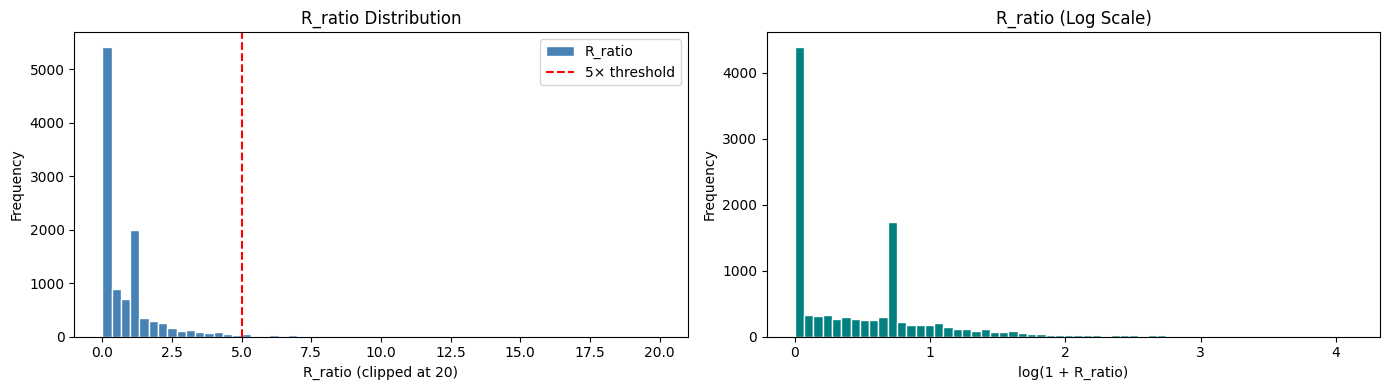

Saved → data/feat_r_ratio.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['R_ratio'].clip(upper=20).plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(5, color='red', linestyle='--', label='5× threshold')
axes[0].set_xlabel('R_ratio (clipped at 20)')
axes[0].set_title('R_ratio Distribution')
axes[0].legend()

np.log1p(df['R_ratio']).plot(kind='hist', bins=60, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_xlabel('log(1 + R_ratio)')
axes[1].set_title('R_ratio (Log Scale)')

plt.tight_layout()
plt.savefig('../data/feat_r_ratio.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → data/feat_r_ratio.png')

## Feature 2 — M_flag (Methodology Risk Flag)

Some project types are historically known to **over-credit** — they generate credits for activities that would have happened anyway without carbon money (a.k.a. low additionality).

**Sources:** Wara 2007, Gillenwater & Seres 2011, Calel et al. 2021

- `M_flag = 1` → high-risk project type  
- `M_flag = 0` → not in the high-risk list (or Type is missing)

In [4]:
HIGH_RISK_TYPES = {
    'Wind',
    'Hydropower',
    'Solar - Centralized',
    'Solar - Distributed',
    'Biomass',
    'Fossil Fuel Switching',
    'Large Hydropower',
    'Renewable Energy',
    'Geothermal',
}

actual_types = set(df['Type'].dropna().unique())
matched   = HIGH_RISK_TYPES & actual_types
unmatched = HIGH_RISK_TYPES - actual_types
print(f'High-risk types in dataset ({len(matched)}): {sorted(matched)}')
print(f'Not found in dataset ({len(unmatched)}):    {sorted(unmatched)}')

df['M_flag'] = df['Type'].apply(
    lambda t: 1 if pd.notna(t) and t in HIGH_RISK_TYPES else 0
)

print(f'\nM_flag=1 (high-risk): {df["M_flag"].sum():,}  ({df["M_flag"].mean()*100:.1f}%)')
print(f'M_flag=0 (low-risk):  {(df["M_flag"]==0).sum():,}')

# Show breakdown by registry for flagged projects
print('\nHigh-risk projects by Type:')
print(df[df['M_flag']==1]['Type'].value_counts().head(10).to_string())

High-risk types in dataset (6): ['Biomass', 'Geothermal', 'Hydropower', 'Solar - Centralized', 'Solar - Distributed', 'Wind']
Not found in dataset (3):    ['Fossil Fuel Switching', 'Large Hydropower', 'Renewable Energy']

M_flag=1 (high-risk): 2,358  (21.5%)
M_flag=0 (low-risk):  8,617

High-risk projects by Type:
Type
Wind                   1025
Hydropower              535
Solar - Centralized     366
Biomass                 299
Solar - Distributed      95
Geothermal               38


## Feature 3 — T_flag (Temporal Spike Flag)

Flag projects where a single year's issuance was **3× larger than their own historical average** AND more than 10,000 credits (to ignore noise from tiny projects).

**Why it matters:** Fraudsters often issue a massive batch of credits in a single year right before abandoning a project — this catches those abnormal spikes.

**Logic:**
- `max_single_year` = max across year columns 1996–2025
- `historical_yearly_avg` = Total Credits Issued ÷ Vintage_Age
- `T_flag = 1` if `max_single_year > 3 × historical_yearly_avg` AND `max_single_year > 10,000`

In [5]:
existing_years = [y for y in YEAR_COLS if y in df.columns]
print(f'Using {len(existing_years)} year columns: {existing_years[0]} → {existing_years[-1]}')

year_data = df[existing_years].apply(pd.to_numeric, errors='coerce')
df['max_single_year'] = year_data.max(axis=1)

vintage_safe = pd.to_numeric(df['Vintage_Age'], errors='coerce').replace(0, np.nan)
df['historical_yearly_avg'] = df[TOTAL_ISSUED] / vintage_safe
df['historical_yearly_avg'] = df['historical_yearly_avg'].fillna(df[TOTAL_ISSUED])

df['T_flag'] = (
    (df['max_single_year'] > 3 * df['historical_yearly_avg']) &
    (df['max_single_year'] > 10_000)
).astype(int)

print(f'T_flag=1 (spiked): {df["T_flag"].sum():,}  ({df["T_flag"].mean()*100:.1f}%)')
print(f'T_flag=0 (normal): {(df["T_flag"]==0).sum():,}')

print('\nTop 8 temporal spike projects:')
print(df[df['T_flag']==1].nlargest(8, 'max_single_year')[
    ['Project ID', 'Voluntary Registry', 'Type', 'max_single_year', 'historical_yearly_avg', 'Vintage_Age']
].to_string(index=False))

Using 30 year columns: 1996 → 2025
T_flag=1 (spiked): 2,201  (20.1%)
T_flag=0 (normal): 8,774

Top 8 temporal spike projects:
Project ID Voluntary Registry                       Type  max_single_year  historical_yearly_avg  Vintage_Age
   VCS1477                VCS                      REDD+         14165124           3.636208e+06         11.0
    ACR360                ACR Improved Forest Management         12502637           1.513171e+06          9.0
    ACR255                ACR Improved Forest Management         12163578           1.269062e+06         10.0
    ACR324                ACR Improved Forest Management          9306732           1.093627e+06         10.0
   VCS1566                VCS                      REDD+          7097573           2.084186e+06         13.0
   CAR1264                CAR Improved Forest Management          6386504           8.452531e+05          8.0
    ACR303                ACR Improved Forest Management          5159212           5.622742e+05        

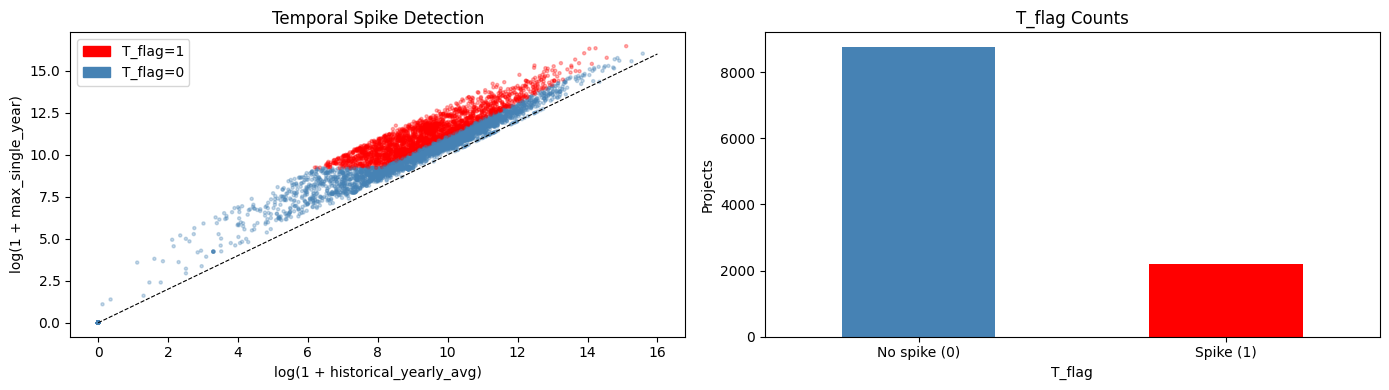

Saved → data/feat_t_flag.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

from matplotlib.patches import Patch
colors = df['T_flag'].map({0: 'steelblue', 1: 'red'})
axes[0].scatter(
    np.log1p(df['historical_yearly_avg']),
    np.log1p(df['max_single_year']),
    c=colors, alpha=0.3, s=5
)
axes[0].plot([0, 16], [0, 16], 'k--', linewidth=0.8)
axes[0].set_xlabel('log(1 + historical_yearly_avg)')
axes[0].set_ylabel('log(1 + max_single_year)')
axes[0].set_title('Temporal Spike Detection')
axes[0].legend(handles=[Patch(color='red', label='T_flag=1'), Patch(color='steelblue', label='T_flag=0')])

df['T_flag'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'red'])
axes[1].set_xticklabels(['No spike (0)', 'Spike (1)'], rotation=0)
axes[1].set_ylabel('Projects')
axes[1].set_title('T_flag Counts')

plt.tight_layout()
plt.savefig('../data/feat_t_flag.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → data/feat_t_flag.png')

## Step 4 — Build & Save `features.csv`

Keep only the 4 numerical features + Project ID + metadata columns for later inspection.  
This is the **only file the Isolation Forest will read**.

In [7]:
features_df = df[[
    'Project ID',
    'Voluntary Registry',
    'Type',
    'Country',
    'R_ratio',
    'Vintage_Age',
    'M_flag',
    'T_flag',
]].copy()

before = len(features_df)
features_df = features_df.dropna(subset=['R_ratio', 'Vintage_Age', 'M_flag', 'T_flag'])
after  = len(features_df)

print(f'Rows kept: {after:,}  (dropped {before - after:,} with NaN features)')
features_df.to_csv('../data/features.csv', index=False)
print(f'\n✅  Saved data/features.csv  ({after:,} rows × {features_df.shape[1]} columns)')

print('\n── Feature summary ─────────────────────────────────────────────')
print(features_df[['R_ratio', 'Vintage_Age', 'M_flag', 'T_flag']].describe().round(2).to_string())

Rows kept: 5,699  (dropped 5,276 with NaN features)

✅  Saved data/features.csv  (5,699 rows × 8 columns)

── Feature summary ─────────────────────────────────────────────
       R_ratio  Vintage_Age   M_flag   T_flag
count  5699.00      5699.00  5699.00  5699.00
mean      1.71        10.25     0.27     0.39
std       2.97         5.46     0.44     0.49
min       0.00         2.00     0.00     0.00
25%       0.35         5.00     0.00     0.00
50%       0.95         9.00     0.00     0.00
75%       1.87        15.00     1.00     1.00
max      60.56        30.00     1.00     1.00


In [8]:
# Preview: what the Isolation Forest will actually see
sample = pd.concat([
    features_df.nlargest(3, 'R_ratio'),
    features_df[features_df['T_flag'] == 1].head(3),
    features_df[features_df['M_flag'] == 1].sample(3, random_state=42),
    features_df.sample(4, random_state=7),
]).drop_duplicates('Project ID')

print('Sample rows — what the model will see:\n')
print(sample[['Project ID', 'Voluntary Registry', 'Type', 'R_ratio', 'Vintage_Age', 'M_flag', 'T_flag']]
      .to_string(index=False))

Sample rows — what the model will see:

Project ID Voluntary Registry                        Type   R_ratio  Vintage_Age  M_flag  T_flag
     GS447               GOLD                  Cookstoves 60.558105         19.0       0       0
   VCS3115                VCS     Sustainable Agriculture 50.000000          9.0       0       0
   VCS2404                VCS Afforestation/Reforestation 47.969627         15.0       0       1
    ACR102                ACR             SF6 Replacement  1.962626         23.0       0       1
    ACR103                ACR     Manure Methane Digester  0.509844         23.0       0       1
    ACR105                ACR Afforestation/Reforestation  1.000000         15.0       0       1
   VCS4187                VCS         Solar - Centralized  0.036500          4.0       1       1
    VCS626                VCS                  Hydropower  0.039672         18.0       1       1
    GS5799               GOLD                        Wind  2.286365          9.0       